## Notebook that loads multi camera recording and does triangulation using mediapipe and ransac

1. Runs the same robust per-camera detection pipeline validated in
   `/tmp/diag_percam7_robust_render.py` (YOLO + MediaPipe detection union, temporal
   tracking, majority-vote handedness resolution, two-signal occlusion flagging) to
   get, for each of the 7 cameras and each frame, MediaPipe's 21 2D hand landmarks
   per hand (when available), plus presence/occlusion flags.


In [15]:
import sys, os, json, time, types, pickle
from itertools import combinations
from collections import Counter
import numpy as np
import cv2
import h5py
import torch
import matplotlib.pyplot as plt


In [5]:
# chech if cuda is available
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cpu


In [16]:
# Load calibration from existing h5 to get camera intrinsics
# Load Chameleon calibration from H5 (same approach as h5_explore.ipynb).
class ChameleonCalibrationV1:
    """Stub for unpickling when calib package is not installed."""
    pass

H5_PATH = '../tmp/Testdata.h5'

calib_mod = types.ModuleType('calib.chameleon_calibration')
calib_mod.ChameleonCalibrationV1 = ChameleonCalibrationV1
sys.modules['calib.chameleon_calibration'] = calib_mod
sys.modules['calib'] = types.ModuleType('calib')


def build_camera_cal(intrin_vec, cam_to_world):
    cx, cy, fx, fy = intrin_vec[2], intrin_vec[3], intrin_vec[4], intrin_vec[5]
    K = np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1]], dtype=np.float64)
    dist = intrin_vec[6:14].astype(np.float64)
    return K, dist


with h5py.File(H5_PATH, 'r') as f:
    cal = pickle.loads(bytes(f['calibration/cal_pickle'][()]))
    camera_ids = sorted(f['rec'].keys())

CAMERA_CALIB = {}
CAMERA_WORLD_TRANSFORMS = {}
PROJECTION_MATRICES = {}
Ks = []
dists = []
widths = []
heights = []

averages_for_undistortion = {}

for i, cam_id in enumerate(camera_ids):
    if cam_id == 'cam02':
        continue

    K, dist = build_camera_cal(cal.intrinsics[i], cal.cam_to_world[i])

    # store for averaging
    Ks.append(K)
    dists.append(dist)

    w, h = cal.intrinsics[i][0], cal.intrinsics[i][1]
    widths.append(w)
    heights.append(h)

    CAMERA_CALIB[cam_id] = {
        'K': K,
        'dist': dist,
        'width': float(w),
        'height': float(h)
    }

    T_cw = cal.cam_to_world[i].astype(np.float64)
    CAMERA_WORLD_TRANSFORMS[cam_id] = T_cw

    T_wc = np.linalg.inv(T_cw)
    PROJECTION_MATRICES[cam_id] = K @ T_wc[:3, :]

    print(f"  {cam_id}: fx={K[0, 0]:.1f}, fy={K[1, 1]:.1f}, cx={K[0, 2]:.1f}, cy={K[1, 2]:.1f}")
    print(f"  Distortion coefficients: {dist}")

N_CAMS = len(camera_ids)
print(f'Loaded ChameleonCalibrationV1 ({cal.n_cameras} cameras, gravity={cal.gravity_world})')
print(f'{N_CAMS} cameras: {camera_ids}')

K_avg = np.mean(np.stack(Ks), axis=0)
dist_avg = np.mean(np.stack(dists), axis=0)

w_avg = float(np.mean(widths))
h_avg = float(np.mean(heights))

averages_for_undistortion = {
    "K": K_avg,
    "dist": dist_avg,
    "width": w_avg,
    "height": h_avg
}

print("\n=== AVERAGED CALIBRATION ===")
print("K_avg =\n", K_avg)
print("dist_avg =", dist_avg)
print("size =", w_avg, "x", h_avg)

  cam00: fx=2014.5, fy=2014.5, cx=1673.0, cy=918.5
  Distortion coefficients: [-3.69948673e+00  6.96727295e+01 -2.14168176e-04  5.69620344e-04
  1.21795568e+01 -3.55453992e+00  6.88847122e+01  2.86591110e+01]
  cam01: fx=1997.1, fy=1997.1, cx=1690.5, cy=956.0
  Distortion coefficients: [-2.52441049e+00  2.43909702e+01  1.86500896e-04  2.51565245e-04
  2.18492889e+00 -2.37144923e+00  2.41450863e+01  7.39158106e+00]
  cam03: fx=2011.3, fy=2011.3, cx=1700.2, cy=926.9
  Distortion coefficients: [ 6.45838642e+00  1.49909830e+01  1.67009726e-04 -1.51016007e-04
 -1.03255522e+00  6.49904013e+00  1.71867447e+01  9.39346969e-01]
  cam04: fx=1995.0, fy=1995.0, cx=1697.7, cy=953.3
  Distortion coefficients: [-2.73455071e+00  2.41850338e+01 -8.48461175e-04 -1.30986271e-03
  2.48986673e+00 -2.57990861e+00  2.38654346e+01  7.70038223e+00]
  cam05: fx=2014.8, fy=2014.8, cx=1728.1, cy=950.2
  Distortion coefficients: [ 3.25177860e+00  2.71459141e+01 -1.68515282e-04 -2.41496426e-04
  1.83440709e+00  3.3

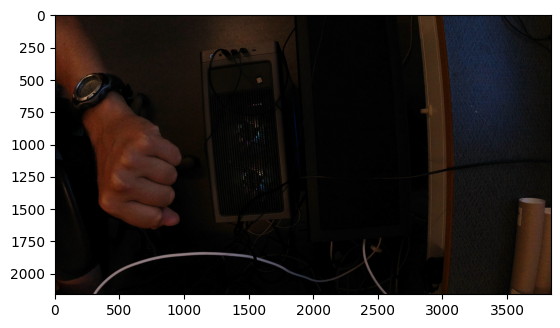

In [42]:
# load a test image

recording_path = 'recordings/sign_capture_20260702_202231_iso800_shutter3000us/aligned'
cam_id = 'cam0'
image = "000000.jpg"

# load image
image_path = os.path.join(recording_path, cam_id, image)
image = cv2.imread(image_path)

# change to rgb
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# show image
plt.imshow(image)
plt.show()


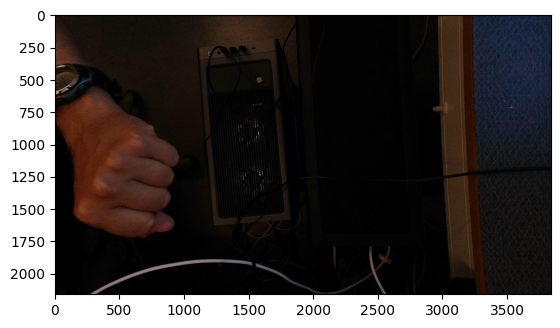

In [43]:
# undistort image using averages    
image = cv2.undistort(image, averages_for_undistortion['K'], averages_for_undistortion['dist'])

# show undistorted image
plt.imshow(image)
plt.show()



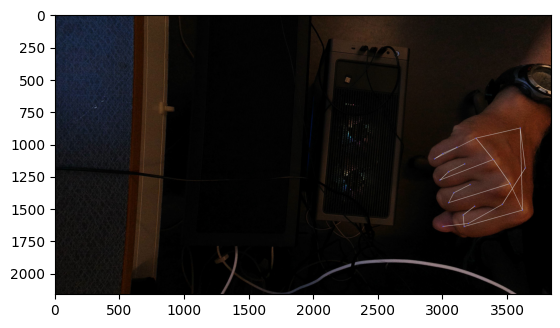

Hand #0: Left with 1.00 confidence


In [44]:
# run mediapipe detection
import mediapipe as mp

# flip image horizontally
image = cv2.flip(image, 1)

# initialize mediapipe hands
hands = mp.solutions.hands.Hands(
    max_num_hands=1,
    min_detection_confidence=0.2,
    min_tracking_confidence=0.5
)

# process image
results = hands.process(image)

#print(dir(results))

# draw landmarks
if results.multi_hand_landmarks:
    #print(results.multi_hand_landmarks)
    for hand_landmarks in results.multi_hand_landmarks:
        mp.solutions.drawing_utils.draw_landmarks(
            image,
            hand_landmarks,
            mp.solutions.hands.HAND_CONNECTIONS
        )

# show image
plt.imshow(image)
plt.show()  

if results.multi_handedness:
    for hand_idx, hand_info in enumerate(results.multi_handedness):
        # Access the classification score (confidence)
        score = hand_info.classification[0].score
        label = hand_info.classification[0].label
        
        print(f"Hand #{hand_idx}: {label} with {score:.2f} confidence")



In [61]:
from tqdm import tqdm

# run mediapipe detection on all images and all cameras and save as json
cam_ids = ['cam0', 'cam1', 'cam2', 'cam3']

# count number of frames
# list dir
image_files = os.listdir(os.path.join(recording_path, cam_id))

# count number of frames
num_frames = len(image_files)
print(f"Number of frames: {num_frames}")
landmarks_all = {}
confidence_all = {}
for cam_id in cam_ids:
    landmarks_all[cam_id] = {}
    confidence_all[cam_id] = {}
    for image_file in tqdm(image_files):
        try:
            image_path = os.path.join(recording_path, cam_id, image_file)
            image = cv2.imread(image_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.undistort(image, averages_for_undistortion['K'], averages_for_undistortion['dist'])

            # run mediapipe detection
            results = hands.process(image)

            # save landmarks and confidence

            if results.multi_hand_landmarks:
                for hand_landmarks in results.multi_hand_landmarks:
                    #print(hand_landmarks.landmark)
                    lms = {}
                    for id, lm in enumerate(hand_landmarks.landmark):
                        lms[id] = [lm.x, lm.y, lm.z]

                    landmarks_all[cam_id][image_file] = lms
            if results.multi_handedness:
                for hand_idx, hand_info in enumerate(results.multi_handedness):
                    # Access the classification score (confidence)
                    score = hand_info.classification[0].score
                    confidence_all[cam_id][image_file] = score

            
        except Exception as e:
            print(f"Error processing image {image_file} for camera {cam_id}: {e}")

        #if image_file == '000003.jpg':
        #    break

# save landmarks and uncertainty
landmarks_path = os.path.join(recording_path,'landmarks.json')

confidence_path = os.path.join(recording_path, 'confidence.json')


with open(landmarks_path, 'w') as f:
    json.dump(landmarks_all, f)
with open(confidence_path, 'w') as f:
    json.dump(confidence_all, f)


# print landmarks_all
print(landmarks_all)
print(confidence_all)

Number of frames: 280


  0%|          | 0/280 [00:00<?, ?it/s]c:\Users\signbot\miniconda3\envs\oak_env\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
100%|██████████| 280/280 [00:37<00:00,  7.52it/s]


{'cam0': {'000000.jpg': {0: [0.06581908464431763, 0.4364805817604065, 1.066976196284486e-08], 1: [0.060541726648807526, 0.5615100860595703, -0.0209041815251112], 2: [0.10166800022125244, 0.6844732761383057, -0.052227579057216644], 3: [0.16672742366790771, 0.7354803085327148, -0.07171734422445297], 4: [0.22302472591400146, 0.7430776953697205, -0.09040239453315735], 5: [0.06954558938741684, 0.7040748000144958, -0.1439843475818634], 6: [0.17209936678409576, 0.7624198198318481, -0.159184530377388], 7: [0.17870977520942688, 0.7141456604003906, -0.13541434705257416], 8: [0.16060177981853485, 0.6795946955680847, -0.11581779271364212], 9: [0.08713404834270477, 0.6114534139633179, -0.1428452581167221], 10: [0.2099446952342987, 0.6859899759292603, -0.16318337619304657], 11: [0.20063897967338562, 0.6380749940872192, -0.1340111941099167], 12: [0.16624599695205688, 0.6066961288452148, -0.11397691816091537], 13: [0.11796379834413528, 0.5237315893173218, -0.13442759215831757], 14: [0.2284300923347473

In [ ]:
# since we dont know the camera extrinsics, we need to triangulate the landmarks, and we do this based on the 30 first frames and mediapipe landmarks



In [49]:
# remove all the json files
for cam_id in cam_ids:  
    file_list = os.listdir(os.path.join(recording_path, cam_id))
    for file in file_list:
        if file.endswith('.json'):
            print(f"Removing {file}")
            os.remove(os.path.join(recording_path, cam_id, file))


Removing 000000_confidence.json
Removing 000000_landmarks.json
Removing 000001_landmarks.json
Removing 000002_landmarks.json
Removing 000003_landmarks.json
Removing 000004_landmarks.json
Removing 000005_landmarks.json
Removing 000006_landmarks.json
Removing 000007_landmarks.json
Removing 000008_landmarks.json
Removing 000009_landmarks.json
Removing 000010_landmarks.json
Removing 000011_landmarks.json
Removing 000012_landmarks.json
Removing 000013_landmarks.json
Removing 000014_landmarks.json
Removing 000015_landmarks.json
Removing 000016_landmarks.json
Removing 000017_landmarks.json
Removing 000018_landmarks.json
Removing 000019_landmarks.json
Removing 000020_landmarks.json
Removing 000021_landmarks.json
Removing 000022_landmarks.json
Removing 000023_landmarks.json
Removing 000024_landmarks.json
Removing 000025_landmarks.json
Removing 000026_landmarks.json
Removing 000027_landmarks.json
Removing 000028_landmarks.json
Removing 000029_landmarks.json
Removing 000030_landmarks.json
Removin